# Import

In [1]:
import torch
import transformers
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import pipeline

device = 0 if torch.cuda.is_available() else -1
print(device)

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/sise/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c104cuda9SetDeviceEi'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
2025-04-06 13:28:51.408949: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-06 13:28:53.081792: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


0


In [2]:
cd ../

/sise/home/shistikk/IndicatorsOfResilience/code


/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
from qlatent.qmnli.qmnli_torch import *
from qlatent.qmnli.qmnli_torch import _QMNLI, QMNLI

In [4]:
# softmax_files = [False, True]
# softmax_files = [True]

def split_question(Q, index, scales, softmax, filters):
  result = []
  for s in scales:
    q = QCACHE(Q(index=index, scale=s))
    for sf in softmax:
      for f in filters:
        if sf:            
            qsf = QSOFTMAX(q,dim=[index[0], s])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print((index, s),sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=s)
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
            
            qsf = QSOFTMAX(q,dim=index[0])
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(index[0],sf,f)
            result.append(qsf_f)
        else:
            qsf = QPASS(q,descupdate={'softmax':''})
            qsf_f = QFILTER(qsf,filters[f],filtername=f)
            print(s,sf,f)
            result.append(qsf_f)
  return result

def dict_pos_neg(pos, neg, w):
  return dict(dict_same_weight(1.0*w/len(pos),pos), **dict_same_weight(-1.0*w/len(neg),neg))

def print_permutations(q):
#     for q in Q1s:
    W = q._pdf['W']
    print(q._descriptor)
    for i, (kmap, w) in enumerate(zip(q._keywords_map, W)):
        context = q._context_template.format_map(kmap)
        answer = q._answer_template.format_map(kmap)
#         sexisem_score = sexisem_classifier(context.strip('.') + ' ' +answer)
        print(f'{i}.',context ,'->', answer, w)
#     break


frequency_weights:SCALE = {
    'never':-4,
    'very rarely':-3,
    'seldom':-2,
    'rarely':-2,
    'frequently':2,
    'often':2,
    'very frequently':3,
    'always':4,    
}
    
intensifiers_fraction_without_none:SCALE={
            "few":1,
            "some":2,
            "many":3,
            "most":4,
            "all":5,
        }
    
binary_frequency_weights = {k: 1 if v > 0 else -1 for k, v in frequency_weights.items()}
rbinary_frequency_weights = {k: -1 if v > 0 else 1 for k, v in frequency_weights.items()}
frequency_pos = [k for k, v in frequency_weights.items() if v > 0]
frequency_neg = [k for k, v in frequency_weights.items() if v < 0]

# Load Model

In [5]:
p = "typeform/distilbert-base-uncased-mnli"
mnli = pipeline("zero-shot-classification",device=0, model=p)
mnli.model_identifier = p

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
# tokenizer = DistilBertTokenizer.from_pretrained("typeform/distilbert-base-uncased-mnli")
# optimizer = AdamW(mnli.model.parameters(), lr=2e-5, weight_decay=0.01)

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
Device set to use cuda:0


In [6]:
# Check how much memory is allocated on the GPU
allocated_memory = torch.cuda.memory_allocated(device)
print(f"Memory allocated on device {device}: {allocated_memory / (1024 ** 3):.2f} GB")

Memory allocated on device 0: 0.25 GB


# Initial Gradients

In [6]:
# Print initial gradients (should be None)
print("Initial Gradients:")
for name, param in mnli.model.named_parameters():
    if param.grad is not None:
        print(f'Gradient for {name}: {param.grad}')
    else:
        print(f'Gradient for {name}: None')

Initial Gradients:
Gradient for distilbert.embeddings.word_embeddings.weight: None
Gradient for distilbert.embeddings.position_embeddings.weight: None
Gradient for distilbert.embeddings.LayerNorm.weight: None
Gradient for distilbert.embeddings.LayerNorm.bias: None
Gradient for distilbert.transformer.layer.0.attention.q_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.q_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.k_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.k_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.v_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.v_lin.bias: None
Gradient for distilbert.transformer.layer.0.attention.out_lin.weight: None
Gradient for distilbert.transformer.layer.0.attention.out_lin.bias: None
Gradient for distilbert.transformer.layer.0.sa_layer_norm.weight: None
Gradient for distilbert.transformer.layer.0.sa_layer_norm.bias: None
Gradient for di

# PHQ9 Questionnaire

## PHQ1

In [7]:
emo_pos=['little interest', 'no pleasure', 'displeasure', 'dissatisfaction']
emo_neg=['pleasure', 'satisfaction']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q1(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I had {index} in doing things.",
            answer_template="It is {frequency} correct.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":1,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Little interest or pleasure in doing things'
            },
            **kwargs
        )
PHQ9Q1s = split_question(PHQ9Q1,  
                      index=["index"],
                      scales=["frequency"],
                      softmax=[False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q1().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q1 =PHQ9Q1s[i]
q1.run(mnli).report()

frequency False unfiltered
frequency False positiveonly
Query time: 1.2658076286315918
Mean score unfiltered [-2.0..2.0]: -0.27456173300743103
Internal consistency (silhouette, correlation) for unfiltered: 0.8737641990778361
Internal consistency (Calinski&Harabasz)  for unfiltered: 141.29835270727037
Internal consistency (Davies&Bouldin) for unfiltered: 0.13593730065588372


index = ['index']
{'index', 'frequency'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:416: FutureWarning: The provided callable <function mean at 0x7ff0000da340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
pleasure,0.0000,0.0889,0.0383,0.0034,0.6231,0.6693,0.3538,0.5588
satisfaction,0.0000,0.0515,0.0204,0.0012,0.6423,0.7120,0.3951,0.7091
displeasure,0.5482,0.5911,0.8244,0.8175,0.0002,0.0044,0.0002,0.0000
dissatisfaction,0.3836,0.5942,0.7880,0.8036,0.0002,0.0044,0.0002,0.0001
little interest,0.2575,0.8201,0.8800,0.9202,0.0002,0.0087,0.0001,0.0001
no pleasure,0.4384,0.7930,0.8942,0.9535,0.0002,0.0202,0.0001,0.0001


index = ['index']
{'index', 'frequency'} {'frequency'} {'index'}
[]
['pleasure', 'satisfaction'] Alpha: 0.9914547113959205
['little interest', 'no pleasure', 'displeasure', 'dissatisfaction'] Alpha: 0.9929061529813984
Global alpha: 0.2168076286761093


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:416: FutureWarning: The provided callable <function mean at 0x7ff0000da340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


In [8]:
# q1.run(mnli)

In [9]:
# q1.effect_size_pos_neg()

## PHQ2

In [8]:
emo_pos=['down', 'depressed', 'hopeless']
emo_neg=['happy', 'hopeful', 'cheerful']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q2(QMNLI):
    def __init__(self, **kwargs ):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index}.",
            answer_template="It is {frequency} correct.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling down, depressed or hopeless'
            },
            **kwargs
        )
PHQ9Q2s = split_question(PHQ9Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q2().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q2 = PHQ9Q2s[i]
q.run(mnli).report()


(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


NameError: name 'q' is not defined

## PHQ3

In [ ]:
emo_neg=['depressive', 'sad', 'gloom']
emo_pos=["benign", 'legitimate',]
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q3(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I {frequency} had trouble falling asleep.",
            answer_template="This sentence is {index}.",
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":3,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble falling asleep, staying asleep, or sleeping too much'
            },
            **kwargs
        )
PHQ9Q3s = split_question(PHQ9Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q3().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q3=PHQ9Q3s[i]
q.run(mnli).report()

## PHQ4

In [ ]:
emo_pos=['tired', 'drained', 'fatigued']
emo_neg=['energized', 'refreshed', 'lively']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q4(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I feel {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":4,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling tired or having little energy'
            },
            **kwargs
        )
PHQ9Q4s = split_question(PHQ9Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q4().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q4=PHQ9Q4s[i]
q.run(mnli).report()

## PHQ5

In [ ]:
emo_pos=['poor appetite', 'been overeating']
emo_neg=['healthy appetite', 'satisfying appetite']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q5(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I had {index}",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":5,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Poor appetite or overeating'
            },
            **kwargs
        )
PHQ9Q5s = split_question(PHQ9Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q5().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q5=PHQ9Q5s[i]
q.run(mnli).report()

## PHQ6

In [ ]:
emo_pos=['I am a failure', 'I am a disappointment', 'I am underachieving', 'I let myself down', 'I let my family down']
emo_neg=['successful ', 'lucky', 'confident']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q6(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I feel {index}.",
            answer_template="It is {frequency} correct.",
            
            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":6,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling bad about yourself - or that you’re a failure or have let yourself or your family down'
            },
            **kwargs
        )
PHQ9Q6s = split_question(PHQ9Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q6().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q6=PHQ9Q6s[i]
q.run(mnli).report()

## PHQ7

In [ ]:
emo_pos=["happy", 'joyful',]
emo_neg=['depressive', 'sad', 'gloom']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q7(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I {frequency} had trouble concentrating.",
            answer_template="This sentence is {index}.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":7,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble concentrating on things, such as reading the newspaper or watching television'
            },
            **kwargs
        )
PHQ9Q7s = split_question(PHQ9Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q7().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q7=PHQ9Q7s[i]
q.run(mnli).report()

## PHQ8

In [ ]:
emo_pos=['fidgetly', 'slowly']
emo_neg=['normally', 'naturally']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q8(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I move or speak {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":8,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Moving or speaking so slowly that other people could have noticed. Or, the opposite - being so fidgety or restless that you have been moving around a lot more than usual'
            },
            **kwargs
        )
PHQ9Q8s = split_question(PHQ9Q8,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q8().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q8=PHQ9Q8s[i]
q.run(mnli).report()

## PHQ9

In [9]:
emo_pos=['suicidal', 'self destructive', 'deadly']
emo_neg=['harmless', 'hopeful', 'positive']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class PHQ9Q9(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have {index} thoughts.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"PHQ9",
              "Factor":"PHQ9",
              "Ordinal":9,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Thoughts that you would be better off dead or of hurting yourself in some way'
            },
            **kwargs
        )
PHQ9Q9s = split_question(PHQ9Q9,
                      index=["index"],
                      scales=["frequency"],
                      softmax=[True, False],
                      filters={'unfiltered':{},
                               "positiveonly":PHQ9Q9().get_filter_for_postive_keywords(['frequency'])
                              },
                      )
i = 0
q9=PHQ9Q9s[i]
q9.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly
model
I did a deep copy
Query time: 0.020679950714111328
Mean score unfiltered [-1.3333333333333333..1.3333333333333333]: -0.08192029595375061
Internal consistency (silhouette, correlation) for unfiltered: 0.5457926392555237
Internal consistency (Calinski&Harabasz)  for unfiltered: 8.030813018182194
Internal consistency (Davies&Bouldin) for unfiltered: 0.5462464225372236


index = ['index']
{'index', 'frequency'} {'frequency'} {'index'}
[]


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:416: FutureWarning: The provided callable <function mean at 0x7ff0000da340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


frequency,never,very rarely,rarely,seldom,frequently,often,very frequently,always
index,,,,,,,,
harmless,0.0677,0.2272,0.1872,0.2275,0.0372,0.1984,0.0314,0.0233
hopeful,0.0000,0.0236,0.0264,0.0067,0.2526,0.2132,0.2384,0.2390
positive,0.0000,0.0170,0.0158,0.0008,0.2470,0.1919,0.2513,0.2761
deadly,0.2986,0.2231,0.2330,0.2346,0.0003,0.0101,0.0003,0.0000
self destructive,0.2650,0.2310,0.1958,0.2147,0.0218,0.0317,0.0399,0.0000
suicidal,0.2795,0.1926,0.2518,0.2583,0.0007,0.0150,0.0020,0.0000


index = ['index']
{'index', 'frequency'} {'frequency'} {'index'}
[]
['harmless', 'hopeful', 'positive'] Alpha: 0.0028104777042432527
['suicidal', 'self destructive', 'deadly'] Alpha: 0.9914869536401274
Global alpha: 0.8791281249824255


/sise/home/shistikk/IndicatorsOfResilience/code/qlatent/qabstract/qabstract_torch.py:416: FutureWarning: The provided callable <function mean at 0x7ff0000da340> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  df = pd.pivot_table(df, values='P', index=index, columns=[scale], aggfunc=np.mean)


In [10]:
# Check how much memory is allocated on the GPU
allocated_memory = torch.cuda.memory_allocated(device)
print(f"Memory allocated on device {device}: {allocated_memory / (1024 ** 3):.2f} GB")

Memory allocated on device 0: 0.88 GB


In [11]:
import sys
sys.getrefcount(mnli)

10

In [13]:
import referrers
print(referrers.get_referrer_graph(mnli))


╙── ZeroShotClassificationPipeline instance (id=140663698197776)
    ├─╼ transformers.pipelines.zero_shot_classification.mnli (global) (id=140663698197776)
    ├─╼ <module>.mnli (local) (id=140663698197776)
    ├─╼ PHQ9Q1.model (instance attribute) (id=140663689530624)
    │   └─╼ PHQ9Q1 (object) (id=140663698131024) (circular ref)
    ├─╼ QFILTER.model (instance attribute) (id=140663689531840)
    │   └─╼ QFILTER (object) (id=140663901583888)
    │       ├─╼ <module>.q1 (local) (id=140663901583888)
    │       ├─╼ qlatent.qabstract.qabstract_torch.q1 (global) (id=140663901583888)
    │       └─╼ list[0] (id=140663689449216)
    │           ├─╼ PHQ9Q1s (global) (id=140663689449216)
    │           └─╼ <module>.PHQ9Q1s (local) (id=140663689449216)
    ├─╼ QPASS.model (instance attribute) (id=140663689542656)
    │   └─╼ QPASS (object) (id=140663690140880)
    ├─╼ QCACHE.model (instance attribute) (id=140663689535040)
    │   └─╼ QCACHE (object) (id=140664048448912)
    ├─╼ PHQ9Q9.model

# GAD7 Questionnaire

In [18]:
softmax_files = [True, False]

## GAD1

In [19]:
emo_pos=['nervous', 'anxious', 'on edge', 'agitated']
emo_neg=['calm', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q1(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index}.",
            answer_template="It is {frequency} correct.",

           dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":1,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling nervous, anxious or on edge'
            },
            **kwargs
        )
GAD7Q1s = split_question(GAD7Q1,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q1().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q1s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


In [20]:
# q.run(mnli)

In [21]:
# q.mean_score()

## GAD2

In [22]:
# emo_pos=['nervous', 'bothered', 'disturbed']
# emo_neg=['peaceful','calm', 'relaxed']
emo_pos = ['worried', 'troubled', 'disturbed']
emo_neg = ['peaceful','calm', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q2(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
              "Factor":"GAD7",
              "Ordinal":2,
              "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Not being able to stop or control worrying'
            },
            **kwargs
        )

GAD7Q2s = split_question(GAD7Q2,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q2().get_filter_for_postive_keywords(['frequency'])
                      },
                      )

i = 0
q=GAD7Q2s[i]
# q.run(mnli).report()

# q=GAD7Q2s[i]
# q.run(mnli2).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD3

In [23]:
emo_pos=['worried', 'anxious', 'nervous', 'bothered']
# emo_neg=['confident', 'tranquil']
emo_neg = ['calm', 'confident', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q3(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index} about different things.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":3,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Worrying too much about different things'
            },
            **kwargs
        )
GAD7Q3s = split_question(GAD7Q3,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q3().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q3s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD4

In [24]:
emo_pos=['trouble', 'difficulty', ]
emo_neg=['no problem', 'an easy time']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q4(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been having {index} relaxing.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":4,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Trouble relaxing'
            },
            **kwargs
        )
GAD7Q4s = split_question(GAD7Q4,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q4().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD5

In [25]:
emo_pos=['restless', 'agitated', 'nervous']
emo_neg=['calm', 'tranquil', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q5(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":5,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Being so restless that it is hard to sit still'
            },
            **kwargs
        )
GAD7Q5s = split_question(GAD7Q5,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q5().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD6

In [26]:
emo_pos=['annoyed', 'irritated', 'frustrated', 'bothered']
emo_neg=['calm', 'tranquil', 'peaceful', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q6(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have become {index}.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":6,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Becoming easily annoyed or irritable'
            },
            **kwargs
        )
GAD7Q6s = split_question(GAD7Q6,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q6().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## GAD7

In [27]:
emo_pos=['afraid', 'scared', 'anxious']
emo_neg=['calm', 'relaxed']
dict_objective = dict_pos_neg(emo_pos, emo_neg,1)

class GAD7Q7(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template="Over the last 2 weeks, I have been feeling {index} about upcoming events.",
            answer_template="It is {frequency} correct.",

            dimensions={
                    "index":dict_objective,
                    "frequency":frequency_weights,
        },
            descriptor = {"Questionnair":"GAD7",
                      "Factor":"GAD7",
                      "Ordinal":7,
                      "Original":'Over the last 2 weeks, how often have you been bothered by the following problems? Feeling afraid as if something awful might happen'
            },
            **kwargs
        )
GAD7Q7s = split_question(GAD7Q7,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={
                          'unfiltered':{},
                               "positiveonly":GAD7Q7().get_filter_for_postive_keywords(['frequency'])
                      },
                      )
i = 0
q=GAD7Q7s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# SOC13 Questionnaire

## SOC4

In [28]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
# kw_attitude_pos = ["indifferent to", "apathetic to"]
# kw_attitude_neg = ["caring about", "interested in"]
dict_attitude = dict_pos_neg(kw_attitude_pos,kw_attitude_neg, 1.0)


class SOCQ4(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="What goes around me is {index} to me.",
#         context_template = "I am {index} what goes around me.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":4,
                      "Original":"Do you have the feeling that you don’t really care what goes on around you? "
        },
        **kwargs,
    )
SOCQ4s = split_question(SOCQ4,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ4().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ4s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC5

In [29]:
kw_attitude_neg = ['surprised by','puzzled by', ]
kw_attitude_pos = ['expecting','anticipating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ5(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I am {frequency} {index} the behavior of people I thought I knew well.",
        answer_template="True.", 
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":5,
                      "Original":"Has it happened in the past that you were surprised by the behavior of people whom you thought you knew well? "
        },
        **kwargs,
    )
SOCQ5s = split_question(SOCQ5,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ5().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ5s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC6

In [30]:
kw_attitude_neg = ["disappointed", 'failed']
kw_attitude_pos = ["supported", "helped"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ6(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="People whom I counted on {frequency} {index} me.",
        answer_template="True.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":6,
                      "Original":"Has it happened that people whom you counted on disappointed you? "
        },
        **kwargs,
    )
SOCQ6s = split_question(SOCQ6,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ6().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ6s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC8

In [31]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ8(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="My life are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":8,
                      "Original":"Until now your life has had: "
        },
        **kwargs,
    )
SOCQ8s = split_question(SOCQ8,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ8().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ8s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC9

In [32]:
kw_attitude_neg = ["unfairly", "unjustly", "with discrimination", "unequally"]
kw_attitude_pos = ["fairly", "justly", "equally"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ9(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I feel that I am being treated {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":9,
                      "Original":"Do you have the feeling that you’re being treated unfairly? "
        },
        **kwargs,
    )
SOCQ9s = split_question(SOCQ9,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ9().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ9s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC12

In [33]:
kw_attitude_neg = ["helpless", "hopeless", 'powerless']
kw_attitude_pos = ["easy", "comfortable", "relaxed"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

dict_index2 = dict_pos_neg(['know'], ["don't know"], 1.0)


class SOCQ12(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__( 
        context_template="In unfamiliar situation I feel {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":12,
                      "Original":"Do you have the feeling that you’re in an unfamiliar situation and don’t know what to do?"
        },
        **kwargs,
    )
SOCQ12s = split_question(SOCQ12,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ12().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ12s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC16

In [34]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ16(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="Things I do every day are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":16,
                      "Original":"Doing the things you do every day is: "
        },
        **kwargs,
    )
SOCQ16s = split_question(SOCQ16,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ16().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ16s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC19

In [35]:
kw_attitude_pos = ["clear", "coherent", 'logical', 'comprehensible']
kw_attitude_neg = ["mixed-up", "confounded"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ19(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I have {index} feelings and ideas.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":19,
                      "Original":"Do you have very mixed-up feelings and ideas? "
        },
        **kwargs,
    )
SOCQ19s = split_question(SOCQ19,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ19().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ19s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC21

In [36]:
# kw_attitude_neg = ["unwanted", 'undesired']
# kw_attitude_pos = ['joyful', 'good',]
kw_attitude_pos = ['face', 'confront', 'acknowledge', 'process', 'accept']
kw_attitude_neg = [ 'ignore', 'avoid', 'dismiss']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ21(QMNLI):
  """
  """

  def __init__(self, **kwargs):
    super().__init__(
#         context_template="I have {index} feelings.",
        context_template="I have feelings inside I would like to {index}.",
        answer_template="It is {frequency} correct.",
        
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":21,
                      "Original":"Does it happen that you have feelings inside you would rather not feel? "
        },
        **kwargs,
    )
SOCQ21s = split_question(SOCQ21,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ21().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ21s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC25

In [37]:
kw_attitude_neg = ["loser", "sad sack"]
kw_attitude_pos = ["winner", "success"]
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ25(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I’m a {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":25,
                      "Original":"Many people—even those with a strong character—sometimes feel like sad sacks (losers) in certain situations. How often have you felt this way in the past? "
        },
        **kwargs,
    )
SOCQ25s = split_question(SOCQ25,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ25().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ25s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC26

In [38]:
kw_attitude_pos = ["estimate in proportion", "judge in proportion",]
kw_attitude_neg = ["overestimate","misjudge",'underestimate']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ26(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I {index} the importence of something that happened.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Comprehensibility",
                      "Ordinal":26,
                      "Original":"When something happened‚ you have generally found that: you overestimated or underestimated its importance, you saw things in the right proportion"
        },
        **kwargs,
    )
SOCQ26s = split_question(SOCQ26,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ26().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ26s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC28

In [39]:
kw_attitude_neg = ["meaningless", "dull", "aimless", 'boring']
kw_attitude_pos = ["meaningful", "interesting", "fulfilling", 'fascinating']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ28(QMNLI):
  """
  """
  def __init__(self, **kwargs):
    super().__init__(
        context_template="The things I do in my daily life are {index} to me.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Meaningfulness",
                      "Ordinal":28,
                      "Original":"How often do you have the feeling that there’s little meaning in the things you do in your daily life? "
        },
        **kwargs,
    )
SOCQ28s = split_question(SOCQ28,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ28().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ28s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## SOC29

In [40]:
kw_attitude_neg = ["out of control", "uncontrollable", 'unmanageable' ]
kw_attitude_pos = ["contained", "collected", 'controlled']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)


class SOCQ29(QMNLI):
  def __init__(self, **kwargs):
    super().__init__(
        context_template="I feel that my feelings are {index}.",
        answer_template="It is {frequency} correct.",
        dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
        descriptor = {"Questionnair":"SOC",
                      "Factor":"Manageability",
                      "Ordinal":29,
                      "Original":"How often do you have feelings that you’re not sure you can keep under control? "
        },
        **kwargs,
    )
SOCQ29s = split_question(SOCQ29,
                      index=["index"],
                      scales=['frequency'],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly": SOCQ29().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q = SOCQ29s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# Neuroticism

## BIG5   13

In [41]:
kw_attitude_pos = ['stressed', 'worried', 'distressed']
kw_attitude_neg = ['calm', 'composed']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q13(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template = "I feel {index} about things",
            answer_template = "It is {frequency} correct.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":13,
            "Original":"I am easily stressed and worry about things."
            },
            **kwargs
        )
BIG5Q13s = split_question(BIG5Q13,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q13().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q13s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


## BIG5   14

In [42]:
kw_attitude_pos = ['distressed', 'upset', 'volatile']
kw_attitude_neg = ['calm', 'composed', 'collected']
dict_attitude = dict_pos_neg(kw_attitude_pos, kw_attitude_neg, 1.0)

class BIG5Q14(QMNLI):
    def __init__(self, **kwargs):
        super().__init__(
            context_template = "I feel emotionally {index}",
            answer_template = "It is {frequency} correct.",
            dimensions={
            "frequency":frequency_weights,
            "index":dict_attitude,
        },
            descriptor = {"Questionnair":"BIG5",
              "Factor":"Neuroticism",
              "Ordinal":14,
            "Original":"I am easily upset and prone to mood swings."
            },
            **kwargs
        )
BIG5Q14s = split_question(BIG5Q14,
                      index=["index"],
                      scales=["frequency"],
                      softmax=softmax_files,
                      filters={'unfiltered':{},
                               "positiveonly":BIG5Q14().get_filter_for_postive_keywords(ignore_set={'frequency'})
                              },
                      )
i = 0
q=BIG5Q14s[i]
# q.run(mnli).report()

(['index'], 'frequency') True unfiltered
frequency True unfiltered
index True unfiltered
(['index'], 'frequency') True positiveonly
frequency True positiveonly
index True positiveonly
frequency False unfiltered
frequency False positiveonly


# Validation of Translation

In [42]:
from pathlib import Path
import warnings
from sentence_transformers import SentenceTransformer, util
from collections import defaultdict

In [43]:
import gc
gc.collect()
torch.cuda.empty_cache()

120

In [44]:
sentence_embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
cola = pipeline("text-classification","mrm8488/deberta-v3-small-finetuned-cola", device=device)

import os
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu

def linguistic_acceptabilities(q, index, scale,question_name, student_id, output_path=Path(''), save_to_file=False):
    score_by_cola_lst=[]
    score_of_semantic_distance_lst=[]
    score_by_bleu_lst=[]
    kmap_lst=[]
    question_name_lst=[]
    description = q._descriptor
    strFactor=description['Factor']
    strOrdinal=str(description.get('Ordinal', 0))
    ##cleaning the string to get the original question
    strOriginal= description['Original']
    strOriginal = 'none' if strOriginal is None else strOriginal
    strOriginal=strOriginal.replace(strFactor,'',1)
    strOriginal=strOriginal.replace(strOrdinal,'',1)
    strOriginal=strOriginal.replace('.','',1)
    strOriginal=strOriginal.strip() #the original question
    rows = []
    
    partial_internal_consistency = partial(q.internal_consistency, filter={}, index=index , scale=scale)
    try:
        silhouette_score = partial_internal_consistency(measure='silhouette_score', metric='correlation')
    except Exception as e:
        print(e)
        print('silhouette_score is set to -1')
        silhouette_score = -1
        
    if hasattr(q, 'linguistic_acceptability'):
        q.linguistic_acceptability['silhouette_score'] = silhouette_score
        return q.linguistic_acceptability

    for kmap in q._keywords_map:
        score = {}
        score['question_name'] = question_name
        context = q._context_template.format_map(kmap)
        answer = q._answer_template.format_map(kmap)
        score['original_question'] = strOriginal


        cola_score = cola(context +" "+ answer)[0].get('score')
        score['cola_score'] = cola_score
        score['param'] = kmap
        strPermutation= context +" "+ answer
        # sentences = [context +" "+ answer]
        score['question_permutation'] = strPermutation
        #Compute embedding for both lists
        embeddings1 = sentence_embedding_model.encode(strOriginal, convert_to_tensor=True)
        embeddings2 = sentence_embedding_model.encode(strPermutation, convert_to_tensor=True)

        #Compute cosine-similarities
        cosine_scores = util.cos_sim(embeddings1, embeddings2)
        score['semantic_similarity'] = cosine_scores.item()

        score['silhouette_score'] = silhouette_score
        rows.append(score)


    filename = output_path / 'linguistic_acceptabilities.csv'
    df = pd.DataFrame(rows)
    df['student_id'] = student_id
    df = df[['student_id', 'question_name','original_question', 'param','question_permutation','cola_score','semantic_similarity','silhouette_score']]
    if save_to_file:
        if filename.exists():
            df.to_csv(filename, index=False, header=None, mode='a', encoding='utf-8-sig')
        else:
            df.to_csv(filename, index=False, encoding='utf-8-sig')
#     print(f"Linguistic acceptabilities saved in {filename}")
    q.linguistic_acceptability = df
    return df

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/convert_slow_tokenizer.py:560: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [45]:
def question_attributes(q):
    score = {}
    score['questionnair']=q._descriptor['Questionnair']
    score['factor']=q._descriptor['Factor']
    score['ordinal']=q._descriptor['Ordinal']
    score['scale']=q._descriptor['scale']
    score['index']=q._descriptor['index']
    score['filter']=q._descriptor['filter']
    score['softmax'] = q._descriptor['softmax']
    score["original"] = q._descriptor['Original']
    score['Q'] = f"{score['questionnair']}{score['factor']}{score['ordinal']}"
    score['context_template'] = q._context_template
    score['answer_template'] = q._answer_template
    score['dimensions'] = q._dimensions
    score['model'] = q.model.model_identifier if q.model else ""
    return score

def get_question_features(q, student_id='student_id', output_path=Path(''), save_to_file=False):
    score = question_attributes(q)
    score['mean_score'] = q.mean_score().detach().numpy()
    index= q._index
    scale= q._scale
    linguistic_df = linguistic_acceptabilities(q, index=index, scale=scale,question_name=score['Q'], student_id=student_id,
                                               output_path=output_path, save_to_file=save_to_file)
    row = linguistic_df[['cola_score','silhouette_score']].mean(axis=0)
    row_dict = dict(row)
    row_dict['semantic_similarity'] = linguistic_df['semantic_similarity'].quantile(0.75)
    score = score | row_dict
    return score

def extract_epoch(model_path):
    if 'epoch-' in model_path.name:
        i = model_path.name.find('epoch-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('epoch-'):j])
        else:
            epoch = int(model_path.name[i+len('epoch-'):])
        
    elif 'checkpoint-' in model_path.name:
        i = model_path.name.find('checkpoint-')
        j = model_path.name.find('_', i)
        if j > 0:
            epoch = int(model_path.name[i+len('checkpoint-'):j])
        else:
            epoch = int(model_path.name[i+len('checkpoint-'):])
    else:
        epoch = 0
    return epoch

def extract_run(model_path):
    try:
        if 'run' in model_path.name:
            for part in model_path.name.split('_'):
                if 'run' in part:
                    return int(part.replace('run', ''))
        else:
            return -1
    except Exception as e:
        print(e)
        return -1

import json

def get_mnli_score(checkpoint_path):
    mnli_score_path = checkpoint_path / 'all_results.json'
    if not mnli_score_path.exists():
        mnli_score_path = checkpoint_path.parent / (checkpoint_path.name + '_mnli_eval') / 'all_results.json'
    if mnli_score_path.exists():
        with open(mnli_score_path) as f:
            return json.load(f)["eval_accuracy"]
    else:
        return -1
    
# def run_questions(questions, mnli_base, mnli_checkpoint, checkpoint, train_process, fintune_dataset, q_range=[5, 0]):
#     if mnli_base is not mnli_checkpoint:
#         take_classifier(mnli_base, mnli_checkpoint)
#     rows = []
#     for q_raw in tqdm(questions):
# #         qname = q_identifier(q)
# #         print(qname)
#         print(q_raw, mnli_checkpoint.model_identifier)
#         q = q_raw.run(mnli_checkpoint)
#         score = get_question_features(q)
#         score['epoch'] = extract_epoch(checkpoint)
#         score['train_process'] = train_process
#         score['dataset'] = fintune_dataset
#         score['run'] = extract_run(checkpoint.parent)
#         score['mnli_score'] = get_mnli_score(checkpoint)
#         score['range'] = (q._weights_flat.min(), q._weights_flat.max())
#         score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
#         rows.append(score)
#         gc.collect()
#         torch.cuda.empty_cache()
#     return rows


def run_questions(questions, mnli_checkpoint, train_process, fintune_dataset, q_range=[5, 0]):    
    rows = []
    checkpoint = Path(mnli_checkpoint.model_identifier)
    for q_raw in tqdm(questions):
        T = time.time()
        q = q_raw.run(mnli_checkpoint)
#         print('run question:', time.time() - T, 'sec')
        T = time.time()
        score = get_question_features(q)
#         print('get features:', time.time() - T, 'sec')
        score['epoch'] = extract_epoch(checkpoint)
        score['train_process'] = train_process
        score['dataset'] = fintune_dataset
        score['run'] = extract_run(checkpoint.parent)
        score['mnli_score'] = get_mnli_score(checkpoint)
        score['range'] = (q._weights_flat.min(), q._weights_flat.max())
        score['ASI_score'] = np.interp(score['mean_score'], [q._weights_flat.min(), q._weights_flat.max()], q_range)
        rows.append(score)
        gc.collect()
        torch.cuda.empty_cache()
    return rows


def calc_scores(questions, checkpoint, output_path, train_process, fintune_dataset, q_range=[5, 0]):
    fix_config(checkpoint)
    mnli_checkpoint = pipeline("zero-shot-classification", str(checkpoint), device=device)
    mnli_checkpoint.model_identifier = str(checkpoint)
    rows = run_questions(questions, mnli_checkpoint, train_process, fintune_dataset=fintune_dataset, q_range=q_range)
    return rows

def add_epochs_to_rows(rows, mlm_epoch, mnli_checkpoint):
    for score in rows:
        score['mlm_epoch'] = mlm_epoch
        score['mnli_checkpoint'] = mnli_checkpoint
    return rows


def write_to_csv(rows, output_path):
    old_score_hostile_df = pd.DataFrame(rows)
    if output_path.exists():
        old_score_hostile_df.to_csv(output_path, index=False, header=None, mode='a')
    else:
        old_score_hostile_df.to_csv(output_path, index=False)

def fix_config(checkpoint):
    if checkpoint.exists():
        with open(checkpoint / 'config.json') as f:
            d1 = json.load(f)
        d1['id2label'] = {'0': 'entailment', '1': 'neutral', '2': 'contradiction'}
        d1['label2id'] = {'contradiction': 2, 'entailment': 0, 'neutral': 1}
        with open(checkpoint / 'config.json', 'w') as f:
            json.dump(d1, f)
    else:
        print(checkpoint, '#### Not exists ####')
        
def calc_for_all_models(Qs, q_range= [5, 0]):
    all_rows = []
    for p in tqdm(mnli_pipelines):
        print(p)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            rows = calc_scores(Qs, Path(p),  Path(p), '->'.join(['base']), 'hostile',
                               use_base_model=False, q_range=q_range)
            rows = add_epochs_to_rows(rows, 0, 0)
            all_rows += rows
    return pd.DataFrame(all_rows)

In [46]:
result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path)

In [30]:
pwd

'/sise/home/shistikk/IndicatorsOfResilience/code'

In [72]:
mnli_pipelines = [
                  'typeform/distilbert-base-uncased-mnli',
                  'ishan/distilbert-base-uncased-mnli',
                  'typeform/mobilebert-uncased-mnli',
                  'typeform/squeezebert-mnli',
#                   'cross-encoder/nli-roberta-base',
#                   'cross-encoder/nli-deberta-base',
#                   'cross-encoder/nli-distilroberta-base',
#                   'cross-encoder/nli-MiniLM2-L6-H768',
#                   'navteca/bart-large-mnli',
#                   'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
#                   'joeddav/bart-large-mnli-yahoo-answers',
#                   'Narsil/deberta-large-mnli-zero-cls',
#                   'seduerr/paiintent',
#                   'microsoft/deberta-large-mnli',
#                   'microsoft/deberta-base-mnli',
#                   'ishan/bert-base-uncased-mnli',
#                   'Alireza1044/albert-base-v2-mnli',
#                   'Intel/bert-base-uncased-mnli-sparse-70-unstructured',
# #                   'yoshitomo-matsubara/bert-large-uncased-mnli',
# #                   'yoshitomo-matsubara/bert-base-uncased-mnli',
# #                   'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
#                   'valhalla/distilbart-mnli-12-6',
]

## Run Questions

In [73]:
questions = GAD7Q1s + GAD7Q2s  + GAD7Q3s + GAD7Q4s + GAD7Q5s + GAD7Q6s + GAD7Q7s + PHQ9Q1s + PHQ9Q2s + PHQ9Q3s + PHQ9Q4s + PHQ9Q5s + PHQ9Q6s + PHQ9Q7s + PHQ9Q8s + PHQ9Q9s
# questions += SOCQ4s + SOCQ5s + SOCQ6s + SOCQ8s + SOCQ9s + SOCQ12s + SOCQ16s + SOCQ19s + SOCQ21s + SOCQ25s + SOCQ26s + SOCQ28s + SOCQ29s
# questions += BIG5Q13s + BIG5Q14s
# questions = SOCQ6s
# questions = PHQ9Q1s + PHQ9Q2s + PHQ9Q3s + PHQ9Q4s + PHQ9Q5s + PHQ9Q6s + PHQ9Q7s + PHQ9Q8s + PHQ9Q9s
update = True

output_path = result_path / f'check_1.csv'
# [str(a) for a in Path('mnli_models/').glob('*_mnli')]
pipelines = mnli_pipelines

if output_path.exists():
    temp_df = pd.read_csv(output_path)
    indexes = temp_df.groupby(['model', 'Q']).count().index.values
    used_models = defaultdict(set)
    for k, v in indexes:
        used_models[k].add(v)
else:
    used_models = {}


for p in tqdm(pipelines):
    print(p)
#     if get_mnli_score(Path(p)) < 0.7 and p not in mnli_pipelines:
#         print('Skip:', p)
#         continue
    with warnings.catch_warnings():
        try:
            warnings.simplefilter("ignore")        
            if p in used_models and not update:
                pipline_questions = []
                for q in questions:
                    if question_attributes(q)['Q'] not in used_models[p]:
                        pipline_questions.append(q)
                    else:
                        print('skip', p, question_attributes(q)['Q'])
            else:
                pipline_questions = questions

            rows = calc_scores(pipline_questions, Path(p),  output_path, '->'.join(['base']), 'hostile',)
            rows = add_epochs_to_rows(rows, 0, 0)
            write_to_csv(rows, output_path) 
            gc.collect()
            torch.cuda.empty_cache()
        except Exception as e:
            print(e)

            
df = pd.read_csv(output_path)
df = df.drop_duplicates(subset=['filter','softmax','model','Q'], keep='last')
df.to_csv(output_path, index=False)

  0%|          | 0/4 [00:00<?, ?it/s]

typeform/distilbert-base-uncased-mnli
typeform/distilbert-base-uncased-mnli #### Not exists ####


The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.
The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.

  2%|▏         | 3/122 [00:00<00:28,  4.13it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



  3%|▎         | 4/122 [00:00<00:28,  4.14it/s]

...


 99%|█████████▉| 121/122 [01:12<00:00,  3.93it/s]

Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)
silhouette_score is set to -1



100%|██████████| 122/122 [01:13<00:00,  1.67it/s]


0

100%|██████████| 4/4 [02:24<00:00, 36.09s/it]


In [74]:
import pingouin as pg

In [75]:
def load_results(csv_path, softmax, positiveonly, value='ASI_score', index='model', colums='Q'):
    df = pd.read_csv(csv_path)
    df['model'] = df['model'].str.replace('/dt/puzis/cnalab/maor/', '')
    if df['softmax'].isna().sum() > 0:
        softmax_filter = df['softmax'].isna()
    else:
        softmax_filter = df['softmax'] == ''
    if softmax:
        df = df[df['softmax'] == str(softmax)]
    else:
        df = df[softmax_filter]
    if value != 'silhouette_score':
        pass
    else:
        df = df[df['silhouette_score'] > -1]
    if positiveonly:
        df = df[df['filter']=="positiveonly"]
    else:
        df = df[df['filter']=="unfiltered"]
    results_df = pd.pivot_table(df, values=value, index=index, columns=colums, aggfunc='mean')
    return results_df


def get_factor_sub_features(factor, data_df):
    factor = factor if isinstance(factor, list) else [factor]
    feature_subset = []
    for subset in factor:
        for c in data_df.columns:
            if str(subset) in c:
#                 if c[c.find(subset):].replace(subset, '').isnumeric():
                feature_subset.append(c)
    return list(set(feature_subset))

## Validation

In [76]:
softmax_soc=['index', 'frequency'] # False, ['index'], ['frequency'], ['index', 'frequency']
# softmax_gad=['emotion', 'intensifier'] # False, ['emotion'], ['intensifier'], ['emotion', 'intensifier']
# softmax_asi=['frequency']
# softmax_asi=False
positiveonly=True

lr = 2e-5
soc_factors = ['Comprehensibility', 'Manageability', 'Meaningfulness', ]
big_factors = ['Neuroticism']
# asi_factors = ['H', 'BI', 'BP', 'BG', 'B']
q_path = result_path / f'check_1.csv'
# all_filters = [softmax_asi]
# all_factors = ['H', 'B']
gad_factors = ['GAD7']
phq_factors = ['PHQ9']

In [77]:
cols = ['semantic_similarity', 'cola_score', 'silhouette_score']

results = []
for softmax_filter in [softmax_soc]:
    q_res = [load_results(q_path,softmax=softmax_filter,positiveonly=False, value=v).mean(axis=0) for v in cols]
    results.append(pd.concat(q_res, axis=1))
    
liguestic_acceptability_df = pd.concat(results, axis=0)
liguestic_acceptability_df.columns=['semantic_similarity', 'cola_score', 'silhouette_score']
liguestic_acceptability_df.to_csv(result_path / 'qmlm_liguestic_acceptability.csv', index=False)
liguestic_acceptability_df.sort_values('silhouette_score')

,semantic_similarity,cola_score,silhouette_score
Q,,,
PHQ9PHQ99,0.485451,0.773650,0.439745
PHQ9PHQ98,0.686993,0.796706,0.501958
PHQ9PHQ95,0.671451,0.680076,0.509824
PHQ9PHQ96,0.508154,0.891674,0.562151
GAD7GAD73,0.625612,0.834006,0.588769
GAD7GAD74,0.734749,0.924410,0.627382
GAD7GAD72,0.461051,0.879951,0.688063
PHQ9PHQ93,0.631983,0.924723,0.712519
PHQ9PHQ94,0.644818,0.895164,0.715656


In [78]:
liguestic_acceptability_df.mean()

semantic_similarity    0.607381
cola_score             0.863151
silhouette_score       0.652601
dtype: float64

In [79]:
liguestic_acceptability_df.std()

semantic_similarity    0.079809
cola_score             0.071878
silhouette_score       0.105965
dtype: float64

In [80]:
def get_factor_sub_features(factor, data_df):
    feature_subset = []
    for subset in factor:
        feature_subset += [c for c in data_df.columns if subset in c]
    return list(set(feature_subset))

In [82]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

print('Cronbach Alpha:')
for subset in gad_factors + phq_factors:
# for subset in asi_factors:
    feature_subset = [c for c in data_df.columns if subset in c]
    alpha = pg.cronbach_alpha(data=data_df[feature_subset])
    print(f'{subset}, Alpha:, {alpha}')

# asi_feature_subset = get_factor_sub_features(soc_factors, data_df)
# alpha = pg.cronbach_alpha(data=data_df[asi_feature_subset])
# print(f'SOC, Alpha:, {alpha}')

Cronbach Alpha:
GAD7, Alpha:, (0.9682721807041653, array([0.838, 0.999]))
PHQ9, Alpha:, (0.968596167790179, array([0.847, 0.999]))


In [83]:
for subset in ['PHQ']:
    feature_subset = [c for c in data_df.columns if subset in c]
#     subset_df = data_df[feature_subset].drop(subset, axis=1)
    subset_df = data_df[feature_subset]
    alpha = pg.cronbach_alpha(data=subset_df)
    print(subset, 'Alpha:', alpha)
    for feature in subset_df.columns:
        sub = [c for c in subset_df.columns if c != feature]
        alpha = pg.cronbach_alpha(data=subset_df[sub])
        print('without:', feature, 'Alpha:', alpha)

PHQ Alpha: (0.968596167790179, array([0.847, 0.999]))
without: PHQ9PHQ92 Alpha: (0.9592629579097965, array([0.792, 0.999]))
without: PHQ9PHQ93 Alpha: (0.9603687716050079, array([0.798, 0.999]))
without: PHQ9PHQ94 Alpha: (0.9633542536461136, array([0.813, 0.999]))
without: PHQ9PHQ95 Alpha: (0.9671290890140366, array([0.832, 0.999]))
without: PHQ9PHQ96 Alpha: (0.9688831967942811, array([0.841, 0.999]))
without: PHQ9PHQ97 Alpha: (0.9601907443870826, array([0.797, 0.999]))
without: PHQ9PHQ98 Alpha: (0.966363663471927, array([0.829, 0.999]))
without: PHQ9PHQ99 Alpha: (0.9677861128590406, array([0.836, 0.999]))


In [85]:
value='mean_score'

results = []
for softmax_filter in [softmax_soc]:
# for softmax_filter in [softmax_asi]:
    results.append(load_results(q_path,softmax=softmax_filter,positiveonly=positiveonly, value=value))
    
data_df = pd.concat(results, axis=1)

filterd_df = pd.DataFrame()
for factor in gad_factors + phq_factors + big_factors:
# for factor in asi_factors:
    feature_subset = get_factor_sub_features([factor], data_df)
    filterd_df[factor] = data_df[feature_subset].mean(axis=1)

# soc_feature_subset = get_factor_sub_features(soc_factors, data_df)
# filterd_df['SOC13'] = data_df[soc_feature_subset].mean(axis=1)
# asi_feature_subset = get_factor_sub_features(asi_factors, data_df)
# filterd_df['ASI'] = data_df[asi_feature_subset].mean(axis=1)

filterd_df.rcorr(method='spearman')

/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/pingouin/correlation.py:1116: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  mat_upper = mat_upper.applymap(replace_pval)


,GAD7,PHQ9,Neuroticism
GAD7,-,***,
PHQ9,1.0,-,
Neuroticism,nan,nan,-


# Train and Validate

In [12]:
from datasets import load_dataset
dataset = load_dataset('multi_nli')

validation_dataset = dataset['validation_matched']

In [53]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]

In [53]:
# questions_pg = questions_phq + questions_gad

In [54]:
def train(questions, epoch, i):
    mnli.model.train()
    mnli.model_identifier = p + f'_e{epoch}'
    
    for Q in questions:
        q = Q[i]
        q.run(mnli)
#         mean_score = 1 - q.mean_score()
#         mean_score = mean_score.to(device) 
        effect_size = q.effect_size() * -1
        effect_size = effect_size.to(device)
#         effect_size_pos_neg = q.effect_size_pos_neg() * -1
#         effect_size_pos_neg = effect_size_pos_neg.to(device)        
        
        optimizer.zero_grad()
#         mean_score.backward()
        effect_size.backward()
#         effect_size_pos_neg.backward()
        optimizer.step()
        

In [46]:
def validate(questions, i, key):
#     total_mean_score = 0
    total_effect_size = 0
    mnli.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(mnli)
#             total_mean_score += q.mean_score()
#             total_effect_size += q.effect_size()
            total_effect_size += q.effect_size_pos_neg()
        
#     avg_val_mean_score = total_mean_score / len(questions)
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key].append(avg_val_mean_score)
#     print('validate average - mean score: {:.4f}'.format(total_mean_score/len(questions)))

In [47]:
def nli_accuracy(model, validation_data):
    correct = 0
    total = 0
    model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    mean_scores['nli'].append(accuracy)
#     return accuracy

In [60]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        if key == 'nli':
            range_plot = list(range(0, 51, 5))
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            range_plot = range(epochs)
            plt.title(f'{titles[idx]} Effect Size Pos-Neg')
            plt.ylabel('Effect Size Pos-Neg')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend()

    plt.tight_layout()
    plt.show()

In [55]:
epochs = 50
mean_scores = {
    'validation_gad': [],
    'validation_soc': [],
    'validation_phq': [],
    'nli' : []
}

for epoch in tqdm(range(epochs), desc="Training Epochs"):
#     print('Epoch: {}'.format(epoch))
    train(questions_soc, epoch, i)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1} - NLI Accuracy Validation")
        nli_accuracy(mnli.model, validation_dataset)
        
    validate(questions_gad, 0, 'validation_gad')
    
    validate(questions_soc, 0, 'validation_soc')
    
    validate(questions_phq, 0, 'validation_phq')
    
    torch.cuda.empty_cache()
      
# plot_mean_scores(mean_scores, epochs)

In [56]:
plot_mean_scores(mean_scores, epochs)

In [49]:
import gc
gc.collect()
torch.cuda.empty_cache()

0

In [49]:
# # Save the model
# mnli.model.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")
# # Save the tokenizer
# mnli.tokenizer.save_pretrained("/dt/puzis/cnalab/karina/distilbert-base-uncased-mnli_e1_phq")

In [50]:
# # Print gradients after backpropagation
# print("\nGradients after Backpropagation:")
# for name, param in mnli.model.named_parameters():
#     if param.grad is not None:
#         print(f'Gradient for {name}: {param.grad}')
# #     else:
# #         print('None')

# Domain Adapted Models

## MLM

In [55]:
from pathlib import Path

In [44]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/mlm_st_distilbert-base-uncased_2e05_high_soc_run1_unfreeze_mnli_1').glob('*checkpoint*')]

In [38]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq',).glob('*checkpoint*')]

In [39]:
# pipelines = sorted(pipelines, key=lambda x: int(x.split('epoch-')[1]))
pipelines

[]

In [46]:
# from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW
# tokenizer = DistilBertTokenizer.from_pretrained("typeform/distilbert-base-uncased-mnli")

The `xla_device` argument has been deprecated in v4.4.0 of Transformers. It is ignored and you can safely remove it from your `config.json` file.


In [58]:
def validate(model, questions, i, key):
#     total_mean_score = 0
    total_effect_size = 0
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
#             total_mean_score += q.mean_score()
            total_effect_size += q.effect_size()
#             total_effect_size += q.effect_size_pos_neg()
        
#     avg_val_mean_score = total_mean_score / len(questions)
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key].append(avg_val_mean_score)
#     print('validate average - mean score: {:.4f}'.format(total_mean_score/len(questions)))

In [59]:
def nli_accuracy(model, validation_data):
    correct = 0
    total = 0
    model.model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = model.tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    mean_scores['nli'].append(accuracy)
#     return accuracy

In [60]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        range_plot = list(range(1, 21))
        if key == 'nli':
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            plt.title(f'{titles[idx]} Mean Score')
            plt.ylabel('Mean Score')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

Training Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_0


Training Epochs:   5%|▌         | 1/20 [01:12<22:59, 72.61s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_1


Training Epochs:  10%|█         | 2/20 [02:24<21:43, 72.43s/it]

...

Training Epochs:  90%|█████████ | 18/20 [21:38<02:24, 72.09s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_18


Training Epochs:  95%|█████████▌| 19/20 [22:50<01:12, 72.17s/it]

pipline: /dt/puzis/cnalab/karina/mnli_models/mlm_st_dtpuziscnalabmaormnli_modelsbert-base-uncased_bgu_mnli_q_phq/checkpoint_epoch_19


Training Epochs: 100%|██████████| 20/20 [24:03<00:00, 72.15s/it]


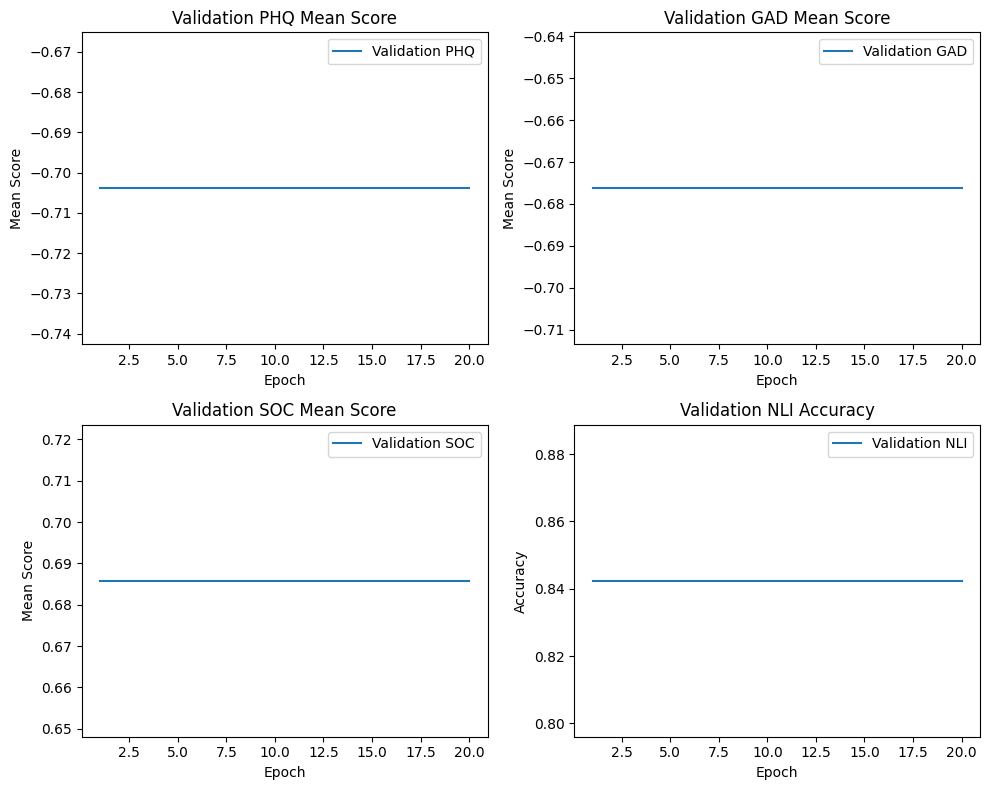

In [61]:
mean_scores = {
    'validation_gad': [],
    'validation_soc': [],
    'validation_phq': [],
    'nli' : []
}

for p in tqdm(pipelines, desc="Training Epochs"):
    print('pipline: {}'.format(p))
    mnli_checkpoint = pipeline("zero-shot-classification", str(Path(p)), device=device)
    mnli_checkpoint.model_identifier = str(Path(p))

    nli_accuracy(mnli_checkpoint, validation_dataset)
        
    validate(mnli_checkpoint, questions_gad, 0, 'validation_gad')
    
    validate(mnli_checkpoint, questions_soc, 0, 'validation_soc')
    
    validate(mnli_checkpoint, questions_phq, 0, 'validation_phq')
    
    torch.cuda.empty_cache()
      
plot_mean_scores(mean_scores, 20)

# Train 109 MNLI models

In [37]:
# mnli_pipelines = [
#                     'typeform/distilbert-base-uncased-mnli',
#                     'ishan/distilbert-base-uncased-mnli',
#                     'typeform/mobilebert-uncased-mnli',
#                     'typeform/squeezebert-mnli',
#                     'cross-encoder/nli-roberta-base',
#                     'cross-encoder/nli-deberta-base',
#                     'cross-encoder/nli-distilroberta-base',
#                     'cross-encoder/nli-MiniLM2-L6-H768',
#                     'navteca/bart-large-mnli',
#                     'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
#                     'joeddav/bart-large-mnli-yahoo-answers',
#                     'Narsil/deberta-large-mnli-zero-cls',
#                     'seduerr/paiintent',
#                     'microsoft/deberta-large-mnli',
#                     'microsoft/deberta-base-mnli',
#                     'ishan/bert-base-uncased-mnli',
#                     'Alireza1044/albert-base-v2-mnli',
#                     'Intel/bert-base-uncased-mnli-sparse-70-unstructured',
#                     'yoshitomo-matsubara/bert-large-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
#                     'valhalla/distilbart-mnli-12-6',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
#                     'cross-encoder/nli-deberta-v3-base',
#                     'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
#                     'tasksource/deberta-small-long-nli',
#                     'joeddav/xlm-roberta-large-xnli',
#                     'MoritzLaurer/DeBERTa-v3-xsmall-mnli-fever-anli-ling-binary',
#                     'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli',
#                     'cross-encoder/nli-deberta-v3-xsmall',
#                     'cross-encoder/nli-deberta-v3-large',
#                     'sileod/deberta-v3-base-tasksource-nli',
#                     'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli',
#                     'sileod/deberta-v3-large-tasksource-nli',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli',
#                     'Narsil/deberta-large-mnli-zero-cls',
#                     'mjwong/multilingual-e5-base-xnli-anli',
#                     'sjrhuschlee/flan-t5-base-mnli',
# ]

In [43]:
mnli_pipelines = [
#                     'typeform/distilbert-base-uncased-mnli',
# #                     'typeform/mobilebert-uncased-mnli',
#                     'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
# #                     'Alireza1044/albert-base-v2-mnli',
# #                     'yoshitomo-matsubara/bert-large-uncased-mnli',
# #                     'yoshitomo-matsubara/bert-base-uncased-mnli',
# #                     'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
#                     'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
#                     'tasksource/deberta-small-long-nli',
#                     'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli',
#                     'sileod/deberta-v3-base-tasksource-nli',
#                     'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli',
#                     'sileod/deberta-v3-large-tasksource-nli',
#                     'MoritzLaurer/DeBERTa-v3-base-mnli',
#                     'mjwong/multilingual-e5-base-xnli-anli',
#                     'sjrhuschlee/flan-t5-base-mnli', 
    "facebook/bart-large-mnli"
]

In [44]:
from pathlib import Path

In [45]:
# pipelines = [str(a) for a in Path('/dt/puzis/cnalab/maor/mnli_models/').glob('*bgu_mnli')]

In [46]:
len(mnli_pipelines)

1

In [2]:
# from datasets import load_dataset
# dataset = load_dataset('multi_nli')

# validation_dataset = dataset['validation_matched']

from datasets import load_dataset
dataset = load_dataset("glue", "mnli")

validation_dataset = dataset['validation_mismatched']

In [47]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]


questions_neuro = [BIG5Q13s , BIG5Q14s]

In [49]:
def train(pipeline, questions, epoch, i):
    pipeline.model.train()
    pipeline.model_identifier = p + f'_epoch_{epoch}'
    
    for Q in questions:
        q = Q[i]
        q.run(pipeline)
        effect_size = q.effect_size() * -1
#         effect_size = q.effect_size()
        effect_size = effect_size.to(device)       
        
        optimizer.zero_grad()
        effect_size.backward()
        optimizer.step()
    return pipeline.model

In [51]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, AdamW

In [52]:
epochs = 21
lr = 1e-5
base_path = Path('/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05')

train_q_list = [
    (questions_phq, 'q_phq'),
    (questions_gad, 'q_gad'),
    (questions_soc, 'q_soc'),
]

for p in tqdm(mnli_pipelines, desc="Training Pipelines"):
    print('pipline: {}'.format(p))
    
    mnli_checkpoint = pipeline("zero-shot-classification", p, device=device)
    mnli_checkpoint.model_identifier = p
    tokenizer = mnli_checkpoint.tokenizer
    optimizer = AdamW(mnli_checkpoint.model.parameters(), lr=lr, weight_decay=0.01)
    
    for questionnaire, suffix in tqdm(train_q_list):
        print(suffix)
        output_dir = base_path / f'mlm_st_{p.replace("/", "")}_{suffix}/'
        output_dir.mkdir(parents=True, exist_ok=True) 
        
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            print('Epoch: {}'.format(epoch))
            if epoch == 0:
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            else:      
                train(mnli_checkpoint, questionnaire, epoch, 0)
                epoch_dir = output_dir / f'checkpoint_epoch_{epoch}'
                mnli_checkpoint.model.save_pretrained(epoch_dir, verbose=False)
                tokenizer.save_pretrained(epoch_dir, verbose=False)
            
            torch.cuda.empty_cache()


Training Pipelines:   0%|          | 0/1 [00:00<?, ?it/s]

pipline: facebook/bart-large-mnli


/home/shistikk/.conda/envs/myenv/lib/python3.11/site-packages/transformers/optimization.py:588: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(

  0%|          | 0/3 [00:00<?, ?it/s]

q_phq




Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'forced_eos_token_id': 2}


...

Epoch: 20


BartForSequenceClassification(
  (model): BartModel(
    (shared): Embedding(50265, 1024, padding_idx=1)
    (encoder): BartEncoder(
      (embed_tokens): BartScaledWordEmbedding(50265, 1024, padding_idx=1)
      (embed_positions): BartLearnedPositionalEmbedding(1026, 1024)
      (layers): ModuleList(
        (0-11): 12 x BartEncoderLayer(
          (self_attn): BartSdpaAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (final_

Some non-default generation parameters are set in the model config. These should go into a GenerationConfig file (https://huggingface.co/docs/transformers/generation_strategies#save-a-custom-decoding-strategy-with-your-model) instead. This warning will be raised to an exception in v4.41.
Non-default generation parameters: {'forced_eos_token_id': 2}


('/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/tokenizer_config.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/special_tokens_map.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/vocab.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/merges.txt',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/added_tokens.json',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20/tokenizer.json')



Training Epochs: 100%|██████████| 21/21 [02:34<00:00,  7.36s/it]

Training Pipelines: 100%|██████████| 1/1 [07:14<00:00, 434.44s/it]


In [53]:
import gc
gc.collect()
torch.cuda.empty_cache()

226

# Validate 109 MNLI models

In [54]:
from pathlib import Path

In [55]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05').glob('*q_*')]

In [56]:
# pipelines = sorted(pipelines, key=lambda x: int(x.split('epoch-')[1]))
pipelines


['/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_phq',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_soc']

In [57]:
len(pipelines)

3

In [58]:
def validate(epoch, model, questions, i, key):
    total_effect_size = 0
    model.model.eval()
    
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
            total_effect_size += q.effect_size()
        
    avg_val_mean_score = total_effect_size / len(questions)
    mean_scores[key][epoch].append(avg_val_mean_score)

In [109]:
def nli_accuracy(model, validation_data = validation_dataset):
    correct = 0
    total = 0
    model.model.eval()  # Set model to evaluation mode

    with torch.no_grad():  # Disable gradient calculation
        for batch in validation_data:
            premise = batch['premise']
            hypothesis = batch['hypothesis']
            label = torch.tensor(batch['label']).to(model.device)  # Convert label to tensor and move to device
            
            inputs = model.tokenizer(premise, hypothesis, return_tensors="pt", truncation=True, padding=True)
            inputs = {k: v.to(model.device) for k, v in inputs.items()}  # Move input tensors to the same device as the model
            
            outputs = model.model(**inputs)
            predictions = torch.argmax(outputs.logits, dim=-1)
            
            correct += (predictions == label).sum().item()
            total += 1

    accuracy = correct / total if total > 0 else 0
    return accuracy

In [58]:
def plot_mean_scores(mean_scores, epochs):
    plt.figure(figsize=(10, 8))
    titles = ['Validation PHQ', 'Validation GAD', 'Validation SOC', 'Validation NLI']
    keys = ['validation_phq', 'validation_gad', 'validation_soc', 'nli']
    
    for idx, key in enumerate(keys):
        plt.subplot(2, 2, idx + 1)
        
        if key == 'nli':
            range_plot = [0,1,10,20]
            plt.title(f'{titles[idx]} Accuracy')
            plt.ylabel('Accuracy')
        else:
            range_plot = list(range(21))
            plt.title(f'{titles[idx]} Mean Score')
            plt.ylabel('Mean Score')

        plt.plot(range_plot, mean_scores[key], marker='', label=titles[idx])
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

In [59]:
import csv
import os

result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path) 
    
output_path = result_path / f'facebook_all_q_1e05.csv'

In [60]:
from typing import Dict, List

epochs = 21

mean_scores: Dict[str, Dict[str, List[float]]] = {
    'validation_gad': {str(i): [] for i in range(epochs)},
    'validation_soc': {str(i): [] for i in range(epochs)},
    'validation_phq': {str(i): [] for i in range(epochs)},
    'validation_neuro': {str(i): [] for i in range(epochs)},
#     'nli': {str(i): [] for i in [0, 1, 10, 20]},
}
    
# Writing to CSV after each pipeline
with open(output_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write header row
    header = ['questionnaire', 'model'] + [str(i) for i in range(epochs)]
    writer.writerow(header)
    

    for p in tqdm(pipelines, desc="pipelines"):
        print('pipline: {}'.format(p))
#         if (p == "/dt/puzis/cnalab/maor/mnli_models/airesearch_wangchanberta-base-att-spm-uncased_bgu_mnli"):
#             continue
        
        folder_path = Path(p)
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            checkpoint_path = folder_path / f'checkpoint_epoch_{epoch}'
    #         checkpoint_path = folder_path
            print(str(Path(checkpoint_path)))
            mnli_checkpoint = pipeline("zero-shot-classification", str(Path(checkpoint_path)), device=device)
            mnli_checkpoint.model_identifier = str(Path(checkpoint_path))

#             if epoch in [0, 1, 10, 20]:
#                 print(f"Epoch {epoch + 1} - NLI Accuracy Validation")
#                 accuracy = nli_accuracy(mnli_checkpoint)  # Replace with your NLI validation function
#                 mean_scores['nli'][str(epoch)].append(accuracy)

            validate(str(epoch), mnli_checkpoint, questions_gad, 0, 'validation_gad')
            validate(str(epoch), mnli_checkpoint, questions_soc, 0, 'validation_soc')
            validate(str(epoch), mnli_checkpoint, questions_phq, 0, 'validation_phq')
            validate(str(epoch), mnli_checkpoint, questions_neuro, 0, 'validation_neuro')


            torch.cuda.empty_cache()
        # Prepare rows for writing
        for questionnaire, data in mean_scores.items():
            row = [
                questionnaire, p,
                *[
                    data[str(i)][-1].item() if data[str(i)] else 'N/A'
                    for i in range(epochs)
                ]
            ]
            writer.writerow(row)
#         for questionnaire, data in mean_scores.items():
#             row = [questionnaire, p] + [data[str(i)][-1] if data[str(i)] else 'N/A' for i in [0, 1, 10, 20]]
#             writer.writerow(row)

#        # Clear mean_scores after each pipeline to avoid duplicate data
        mean_scores = {
            'validation_gad': {str(i): [] for i in range(epochs)},
            'validation_soc': {str(i): [] for i in range(epochs)},
            'validation_phq': {str(i): [] for i in range(epochs)},
            'validation_neuro': {str(i): [] for i in range(epochs)},
#             'nli': {str(i): [] for i in [0, 1, 10, 20]},
        }


74

pipelines:   0%|          | 0/3 [00:00<?, ?it/s]

pipline: /dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_phq



Training Epochs:   0%|          | 0/21 [00:00<?, ?it/s]

/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_0



Training Epochs:   5%|▍         | 1/21 [00:14<04:56, 14.82s/it]

/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/1e05/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_1


pipelines:   0%|          | 0/3 [00:28<?, ?it/s]


KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_phq model - on validation_gad effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

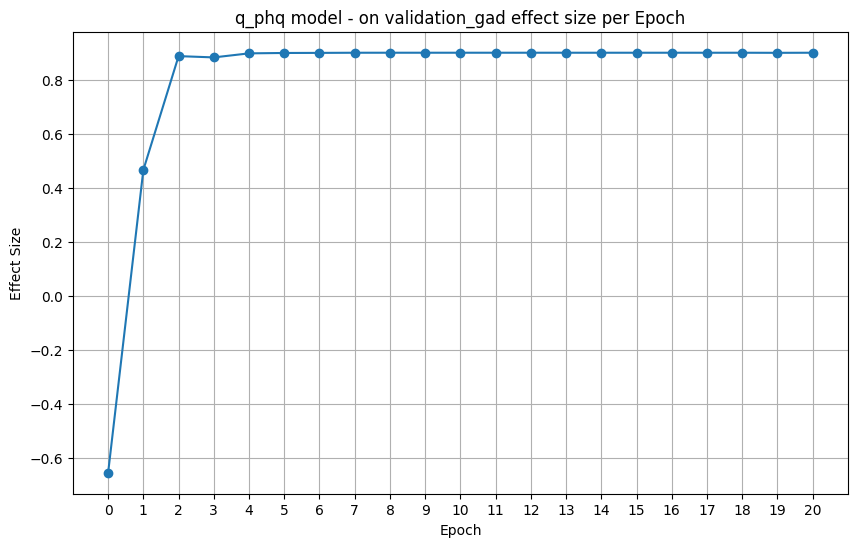

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_phq model - on validation_phq effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

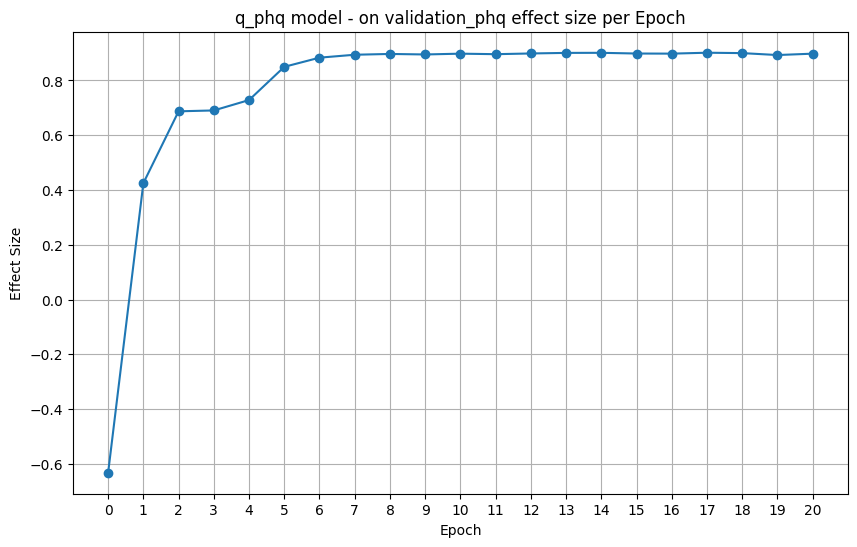

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_phq model - on validation_soc effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

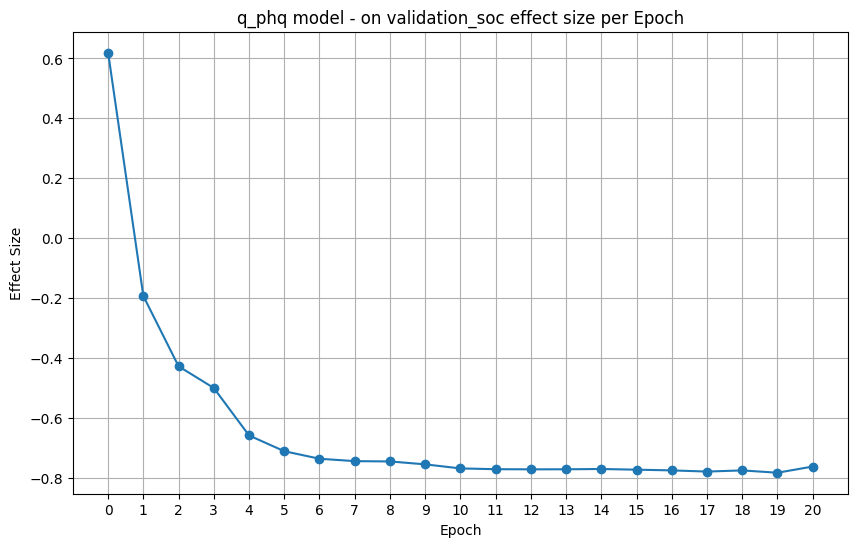

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_phq model - on validation_neuro effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

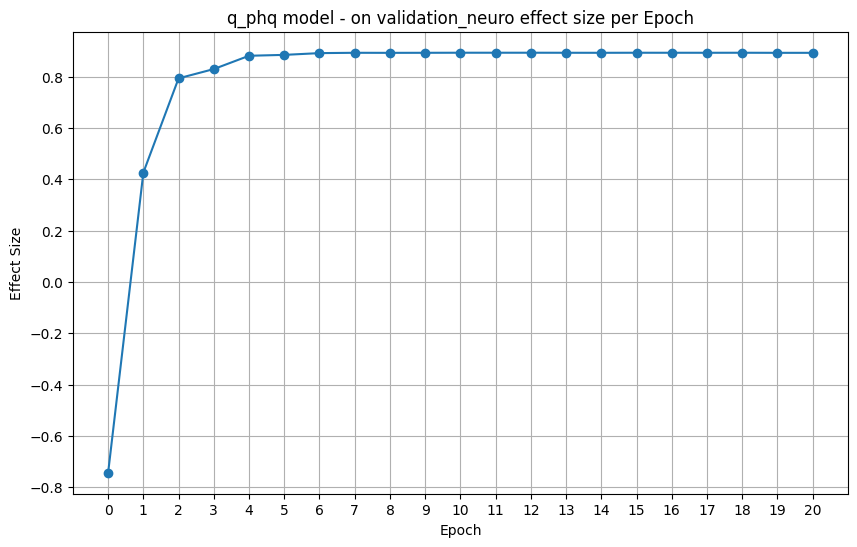

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_gad model - on validation_gad effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

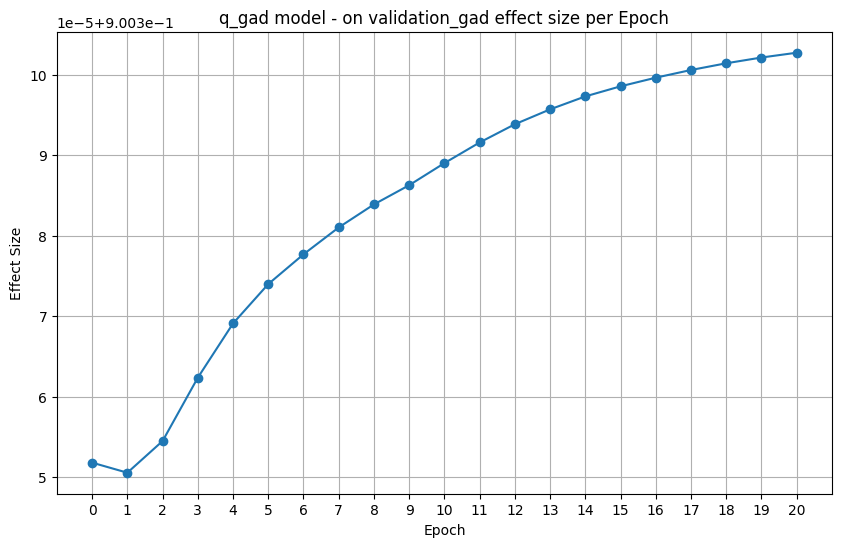

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_gad model - on validation_phq effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

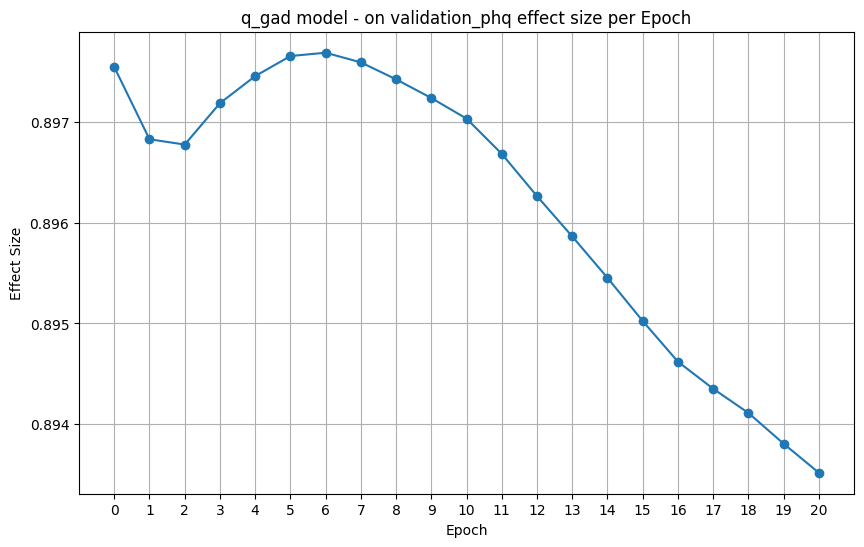

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_gad model - on validation_soc effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

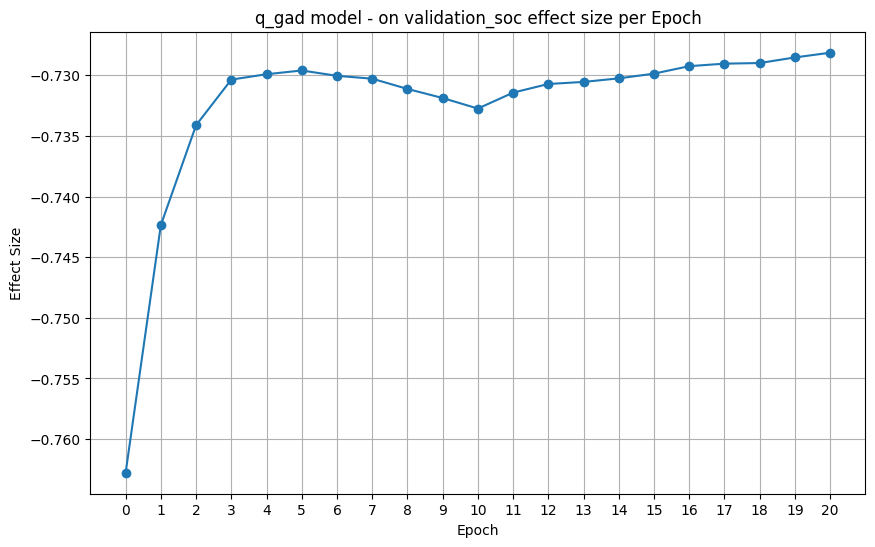

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_gad model - on validation_neuro effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

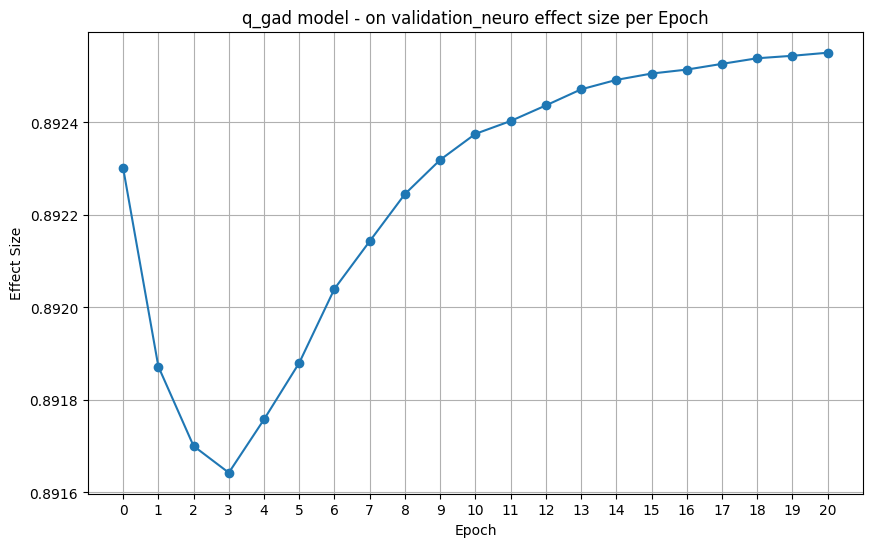

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_soc model - on validation_gad effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

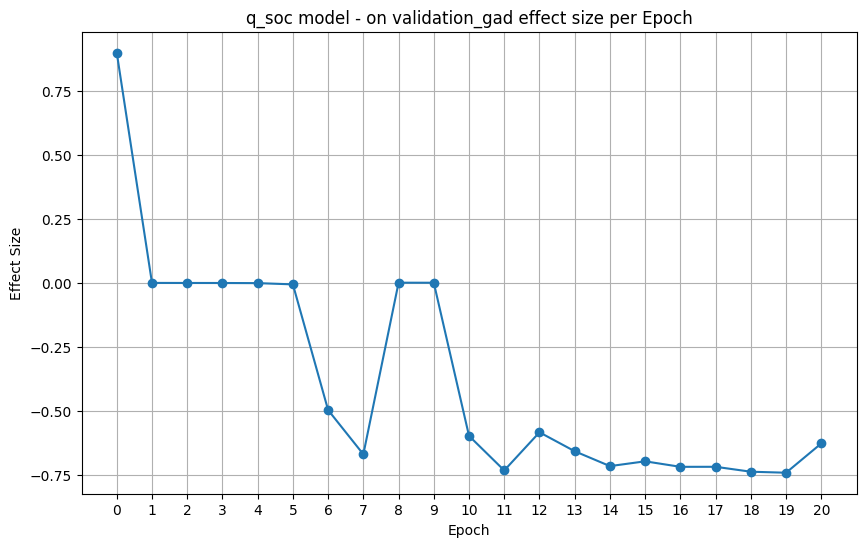

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_soc model - on validation_phq effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

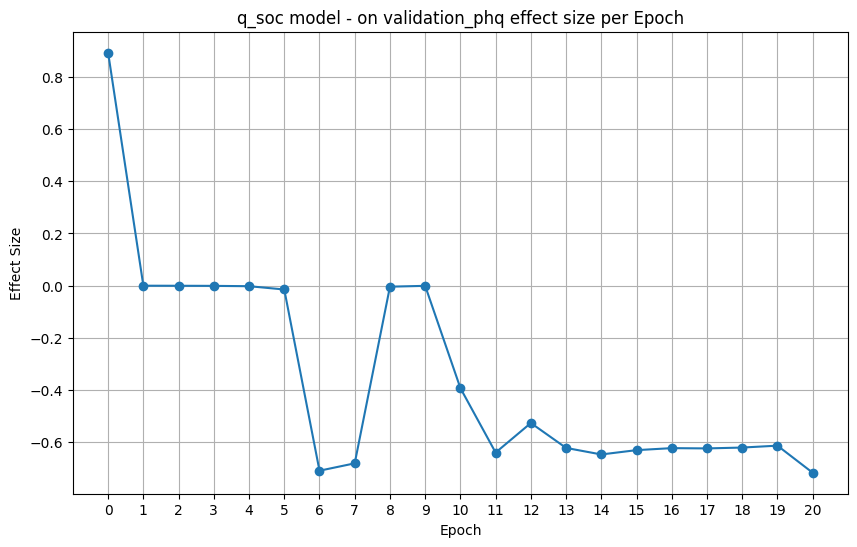

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_soc model - on validation_soc effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

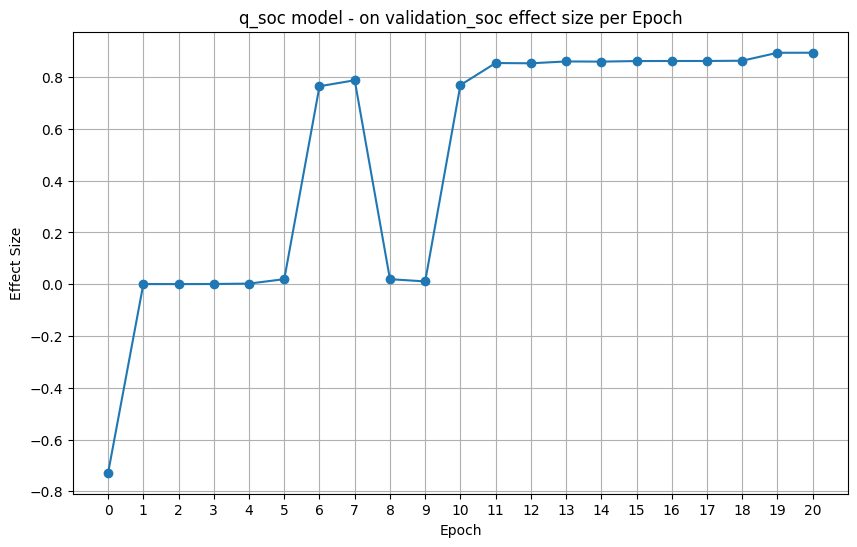

<Figure size 1000x600 with 0 Axes>

Text(0.5, 1.0, 'q_soc model - on validation_neuro effect size per Epoch')

Text(0.5, 0, 'Epoch')

Text(0, 0.5, 'Effect Size')

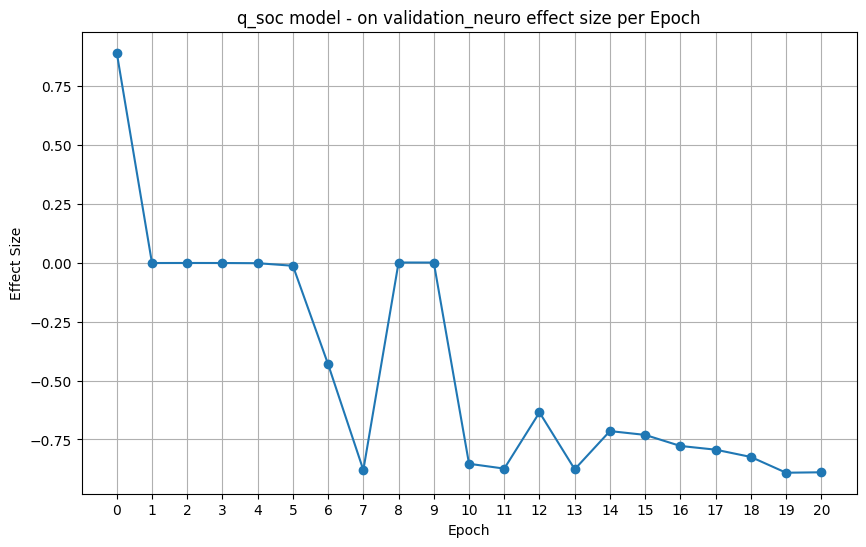

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
# csv_path = '/path/to/your/csvfile.csv'  # Replace with your CSV file path
data = pd.read_csv(output_path)
# data = data[data['model'].isin(models_list)]

# Define model types and validation types
model_types = ['q_phq', 'q_gad', 'q_soc']
# model_types = ['q_soc']
validation_types = ['validation_gad', 'validation_phq', 'validation_soc', 'validation_neuro']
# validation_types = ['nli']
# validation_types = ['validation_neuro']
# validation_types = ['validation_soc']

# Loop through each model type and validation type to calculate mean and create plots
for model_type in model_types:
    for validation_type in validation_types:
        # Filter data for the specific model type and validation type
        filtered_data = data[data['model'].str.contains(model_type) & (data['questionnaire'] == validation_type)]
        
        # Drop columns 'questionnaire' and 'model' to focus only on epochs
        epoch_data = filtered_data.drop(columns=['questionnaire', 'model'])
        
        # Calculate the mean score for each epoch across all rows
        mean_scores = epoch_data.mean(axis=0)
        
        # Plot the mean score over epochs
        plt.figure(figsize=(10, 6))
        plt.plot(mean_scores.index, mean_scores.values, marker='o', linestyle='-')
        plt.title(f'{model_type} model - on {validation_type} effect size per Epoch')
        plt.xlabel('Epoch')
        plt.ylabel('Effect Size')
        plt.grid(True)
        
        # Save the plot with a descriptive filename
        plt.savefig(result_path / f'{model_type}_{validation_type}_facebook_1e05.png')
        
        # Optionally, display the plot
        plt.show()


In [32]:
# models_list = data['model'].tolist()

In [39]:
# data

In [58]:
# mean_mean_scores = {
#     'validation_gad': [],
#     'validation_soc': [],
#     'validation_phq': [],
#     'nli' : []
# }


# for key, inner_dict in mean_scores.items():
#     if inner_dict:  # Check if the inner dictionary is not empty
#         for score_list in inner_dict.values():
#             # Calculate the average of the current score list
#             if score_list:  # Ensure the list is not empty
#                 mean = sum(score_list) / len(score_list)
#                 mean_mean_scores[key].append(mean)

In [75]:
# plot_mean_scores(mean_mean_scores, 21)

In [76]:
# mean_scores

# Reality Check

In [44]:
mnli_pipelines = [
                    'typeform/distilbert-base-uncased-mnli',
#                     'typeform/mobilebert-uncased-mnli',
                    'digitalepidemiologylab/covid-twitter-bert-v2-mnli',
#                     'Alireza1044/albert-base-v2-mnli',
#                     'yoshitomo-matsubara/bert-large-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli',
#                     'yoshitomo-matsubara/bert-base-uncased-mnli_from_bert-large-uncased-mnli',
                    'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli',
                    'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli',
                    'tasksource/deberta-small-long-nli',
                    'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli',
                    'sileod/deberta-v3-base-tasksource-nli',
                    'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli',
                    'sileod/deberta-v3-large-tasksource-nli',
                    'MoritzLaurer/DeBERTa-v3-base-mnli',
                    'mjwong/multilingual-e5-base-xnli-anli',
                    'sjrhuschlee/flan-t5-base-mnli',  
]

In [45]:
from pathlib import Path

In [58]:
pipelines=[str(a) for a in Path('/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2').glob('*q_gad*')]

In [60]:
pipelines

['/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_digitalepidemiologylabcovid-twitter-bert-v2-mnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-base-mnli-fever-anli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurermDeBERTa-v3-base-mnli-xnli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_tasksourcedeberta-small-long-nli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-large-mnli-fever-anli-ling-wanli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_sileoddeberta-v3-base-tasksource-nli_q_gad',
 '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurermultilingual-MiniLMv2-L6-mnli-xnli_q_gad',
 '/dt/puzis/cnalab

In [53]:
questions_gad = [
    GAD7Q1s, GAD7Q2s, GAD7Q3s, GAD7Q4s, GAD7Q5s, GAD7Q6s, GAD7Q7s,
]

questions_soc = [
    SOCQ4s, SOCQ5s, SOCQ6s, SOCQ8s, SOCQ9s, SOCQ12s, SOCQ16s, SOCQ19s,
    SOCQ21s, SOCQ25s, SOCQ26s, SOCQ28s, SOCQ29s,
]

questions_phq = [PHQ9Q1s , PHQ9Q2s , PHQ9Q3s , PHQ9Q4s , PHQ9Q5s , PHQ9Q6s , PHQ9Q7s , PHQ9Q8s , PHQ9Q9s]


questions_neuro = [BIG5Q13s , BIG5Q14s]

In [62]:
def validate(epoch, model, questions, i, key):
    total_mean_score = 0
    model.model.eval()
    i = 1
    with torch.no_grad():
        for Q in questions:
            q = Q[i]
            q.run(model)
#             total_mean_score += q.mean_score()

#             avg_val_mean_score = total_mean_score / len(questions)
            df[str(i)][epoch].append(q.mean_score().item())

In [63]:
import csv
import os

result_path = Path('../results/')
if not result_path.exists():
    os.makedirs(result_path) 
    
output_path = result_path / f'gad_model_phq_q_mean_score.csv'

In [67]:
# Re-import necessary libraries and recreate the requested DataFrame

import pandas as pd

# Define questions and models
questions = list(range(1, 10))  # Questions from 1 to 9
models = [
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_digitalepidemiologylabcovid-twitter-bert-v2-mnli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-base-mnli-fever-anli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurermDeBERTa-v3-base-mnli-xnli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_tasksourcedeberta-small-long-nli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-large-mnli-fever-anli-ling-wanli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_sileoddeberta-v3-base-tasksource-nli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurermultilingual-MiniLMv2-L6-mnli-xnli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_sileoddeberta-v3-large-tasksource-nli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_MoritzLaurerDeBERTa-v3-base-mnli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_mjwongmultilingual-e5-base-xnli-anli_q_gad',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_sjrhuschleeflan-t5-base-mnli_q_gad',
]

# Create the DataFrame
columns = ["question", "model"] + list(range(21))  # 21 epochs
data = []

# Populate the DataFrame with all combinations of questions and models
for question in questions:
    for model in models:
        row = [question, model] + [None] * 21  # Placeholder for epoch scores
        data.append(row)

df = pd.DataFrame(data, columns=columns)


In [71]:
# Get the row where question == 3 and model == 'some_model_name'
row = df[(df["question"] == 3) & (df["model"] == "/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_gad")]

# Access a cell in that row
row.iloc[0, 2] = 0.8 # Access column at index 2 of the matched row


In [72]:
df

,question,model,0,1,2,3,4,5,6,7,...,11,12,13,14,15,16,17,18,19,20
0,1,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
1,1,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
2,1,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
3,1,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
4,1,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,9,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
104,9,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
105,9,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
106,9,/dt/puzis/cnalab/karina/mnli_models/hugging_fa...,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [74]:
row = df[(df["question"] == 3) & (df["model"] == "/dt/puzis/cnalab/karina/mnli_models/hugging_face/mean_score/v2/mlm_st_typeformdistilbert-base-uncased-mnli_q_gad")]

# Access a cell in that row
print(row.iloc[0, 2]) # Access column at index 2 of the matched row


None


In [64]:
from typing import Dict, List

epochs = 21

# mean_scores: Dict[str, Dict[str, list(float)]] = {
# #     'validation_gad': {},
# #     'validation_soc': {},
# #     'validation_phq': {},
# #     'validation_neuro': {}
#     "1" : {str(i) : [] for i in range(epochs)},
#     "2" : {str(i) : [] for i in range(epochs)},
#     "3" : {str(i) : [] for i in range(epochs)},
#     "4" : {str(i) : [] for i in range(epochs)},
#     "5" : {str(i) : [] for i in range(epochs)},
#     "6" : {str(i) : [] for i in range(epochs)},
#     "7" : {str(i) : [] for i in range(epochs)},
#     "8" : {str(i) : [] for i in range(epochs)},
#     "9" : {str(i) : [] for i in range(epochs)}   
# }
        
# Writing to CSV after each pipeline
with open(output_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Write header row
    header = ['questionnaire', 'model'] + [str(i) for i in range(epochs)]
    writer.writerow(header)
    

    for p in tqdm(pipelines, desc="pipelines"):
        print('pipline: {}'.format(p))
        
        folder_path = Path(p)
        for epoch in tqdm(range(epochs), desc="Training Epochs"):
            checkpoint_path = folder_path / f'checkpoint_epoch_{epoch}'
    #         checkpoint_path = folder_path
            print(str(Path(checkpoint_path)))
            mnli_checkpoint = pipeline("zero-shot-classification", str(Path(checkpoint_path)), device=device)
            mnli_checkpoint.model_identifier = str(Path(checkpoint_path))
            
#         validate(str(p), mnli_checkpoint, questions_gad, 0, 'validation_gad')
#         validate(str(p), mnli_checkpoint, questions_soc, 0, 'validation_soc')
            validate(str(p), mnli_checkpoint, questions_phq, 0, 'validation_phq')
#         validate(str(p), mnli_checkpoint, questions_neuro, 0, 'validation_neuro')


            torch.cuda.empty_cache()
        # Prepare rows for writing
#         for questionnaire, data in mean_scores.items():
#             row = [
#                 questionnaire, p,
#                 *[
#                     data[str(i)][-1].item() if data[str(i)] else 'N/A'
#                     for i in range(epochs)
#                 ]
#             ]
#             writer.writerow(row)

#         mean_scores: Dict[str, Dict[str, float]] = {
#             'validation_gad': {},
#             'validation_soc': {},
#             'validation_phq': {},
#             'validation_neuro': {}
#         }


TypeError: 'type' object is not iterable

In [73]:
mean_scores

{'validation_gad': {'typeform/distilbert-base-uncased-mnli': -0.0905650407075882,
  'digitalepidemiologylab/covid-twitter-bert-v2-mnli': -0.07898080348968506,
  'MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli': -0.027433941140770912,
  'MoritzLaurer/mDeBERTa-v3-base-mnli-xnli': -0.037964023649692535,
  'tasksource/deberta-small-long-nli': -0.021572640165686607,
  'MoritzLaurer/DeBERTa-v3-large-mnli-fever-anli-ling-wanli': -0.06692491471767426,
  'sileod/deberta-v3-base-tasksource-nli': -0.005306591745465994,
  'MoritzLaurer/multilingual-MiniLMv2-L6-mnli-xnli': -0.011306235566735268,
  'sileod/deberta-v3-large-tasksource-nli': -0.0854840874671936,
  'MoritzLaurer/DeBERTa-v3-base-mnli': -0.019634990021586418,
  'mjwong/multilingual-e5-base-xnli-anli': -0.045530054718256,
  'sjrhuschlee/flan-t5-base-mnli': -0.05928453058004379},
 'validation_soc': {'typeform/distilbert-base-uncased-mnli': 0.0895218551158905,
  'digitalepidemiologylab/covid-twitter-bert-v2-mnli': 0.06573742628097534,
  'Mori

In [74]:
import csv


# Get all model names as columns
models = sorted({model for scores in mean_scores.values() for model in scores.keys()})

# Prepare the CSV content
csv_data = [["Validation"] + models]

for task, scores in mean_scores.items():
    row = [task] + [scores.get(model, "") for model in models]
    csv_data.append(row)

# Write to CSV
with open(output_path, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(csv_data)

output_path


PosixPath('../results/mnli_q_mean_score.csv')

In [3]:
p = "facebook/bart-large-mnli"
model = pipeline("zero-shot-classification",device=0, model=p)

In [27]:
mnli_pipelines = [
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_20',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_gad/checkpoint_epoch_20',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_20',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_10',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_gad/checkpoint_epoch_10',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_10',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_1',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_gad/checkpoint_epoch_1',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_1',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_phq/checkpoint_epoch_0',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_gad/checkpoint_epoch_0',
    '/dt/puzis/cnalab/karina/mnli_models/hugging_face/facebook/mlm_st_facebookbart-large-mnli_q_soc/checkpoint_epoch_0',

]

In [4]:
validation_data = validation_dataset

In [6]:
import pandas as pd
val_df = pd.DataFrame(validation_data)
sentences = val_df['premise'] + model.tokenizer.sep_token + val_df['hypothesis']

In [7]:
# p = mnli_pipelines[0]
model = pipeline("text-classification",device=0, model=p, batch_size=16)

In [9]:
# for p in tqdm(mnli_pipelines):
#     print(p)
import numpy as np
model = pipeline("text-classification",device=0, model=p, batch_size=16)

preds = []
labels = val_df['label'].map({2: 'contradiction', 1: 'neutral', 0: 'entailment'}).tolist()
for i in range(0, len(sentences), 16):
    results = model(sentences[i:i+16].tolist())
    preds += [res['label'] for res in results]

accuracy = (np.array(preds) == np.array(labels)).sum() / len(preds)
print(accuracy)

0.9002237591537836
